# cs 496 tf-idf training

In [1]:
# Run once in Colab / Jupyter if packages are missing
!pip install -q pandas numpy scikit-learn matplotlib pyarrow nltk tqdm transformers accelerate torch datasets

# imports

In [2]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

N_SAMPLES = 1000
pd.set_option('display.max_colwidth', 250)

In [4]:
df = pd.read_csv("cleaned_data.csv")
df.head()

,Unnamed: 0,index,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,body,sentiment,label,label_clean
0,0,0,i2xzv3o,2qh68,canada,False,1648787181,>I know its no use arguing with you because you seem to have a holier than thou type approach to the Earth's climate. And it's no use arguing with you because somehow you've convinced yourself that you're more qualified to make assessments about ...,0.7460,"""Climate denial critique""",climate denial critique
1,1,1,igzonpx,340dk,askanaustralian,False,1658365540,"i'm a believer in climate change, don't get me wrong. but early 1900s melbourne was very much like this during winter",0.3854,"""Climate opinion""",climate opinion
2,2,2,esa0yio,2r7hk,tumblr,False,1561749008,"Nice try, tumblr SJWs. That animal is a myth, and so is climate change.",0.4215,"""Climate denial""",climate denial
3,3,3,em6p8mh,2qhw9,collapse,False,1556670814,I never disregarded the scientific consensus on anthropogenic climate change. I'm interested on the what's consensus on inevitable near-term collapse amongst climate scientists.,0.1739,"""Climate information""",climate information
4,4,4,chveb1w,2s7tt,adviceanimals,False,1401504754,"So we'll melt the ice caps, cause mass extinction due to climate change.... but at least we have fewer landfills, right?",0.0000,"""climate action critique""",climate action critique


# data preporcessing

In [5]:
import re

def clean_text(text):
    text = str(text)
    # remove urls
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # remove reddit usernames/subreddits
    text = re.sub(r"/u/\w+|u/\w+|/r/\w+|r/\w+", " ", text)
    # html cleanup
    text = re.sub(r"&amp;", "and", text)
    # keep letters/numbers/basic punctuation
    text = re.sub(r"[^A-Za-z0-9\s\.,!?'\-]", " ", text)
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["body"].apply(clean_text)
df = df[
    df["clean_text"].str.len().between(20, 1500)
].reset_index(drop=True)
print("Rows after cleaning:", len(df))
df[["clean_text"]].head()

Rows after cleaning: 15088


,clean_text
0,"i'm a believer in climate change, don't get me wrong. but early 1900s melbourne was very much like this during winter"
1,"Nice try, tumblr SJWs. That animal is a myth, and so is climate change."
2,I never disregarded the scientific consensus on anthropogenic climate change. I'm interested on the what's consensus on inevitable near-term collapse amongst climate scientists.
3,"So we'll melt the ice caps, cause mass extinction due to climate change.... but at least we have fewer landfills, right?"
4,"Overpopulation is a whole world issue. Yes there is a lot of evidence to it and climate change. You need to learn how science works. If you think the science just shows that the world is overpopulated, then you don't understand science. Earth can..."


# TF-IDF + Logistic Regression baseline


Label counts:
label_clean
climate information          9152
climate policy critique      1828
climate action critique       677
climate nihilism              644
climate activism              624
climate denial                469
climate denial critique       445
not climate opinion           406
climate change importance     345
climate anxiety               306
climate opinion critique       76
climate optimism               38
climate apathy                 38
climate nihilism critique      25
climate activism critique       9
climate opinion                 5
Name: count, dtype: int64
Using labels: ['climate information', 'climate policy critique', 'climate action critique', 'climate nihilism', 'climate activism', 'climate denial', 'climate denial critique', 'not climate opinion', 'climate change importance', 'climate anxiety', 'climate opinion critique', 'climate optimism', 'climate apathy', 'climate nihilism critique', 'climate activism critique', 'climate opinion']
Training rows

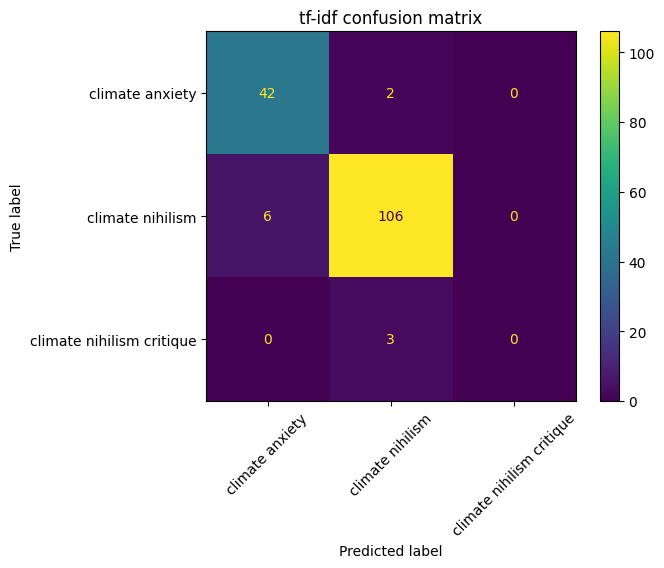

In [9]:
label_counts = df["label_clean"].value_counts()
valid_labels = label_counts[label_counts >= 2].index.tolist()
model_df = df[df["label_clean"].isin(valid_labels)].copy()

print("Label counts:")
print(label_counts)
print("Using labels:", valid_labels)
print("Training rows:", len(model_df))

if len(valid_labels) < 2:
    print("Not enough label classes for Logistic Regression.")
    print("You need at least 2 different labels.")
    print("Right now, all or almost all examples are labeled as 'other'.")
    print("Next step: improve weak labeling OR manually label 100-200 examples first.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        model_df["clean_text"],
        model_df["label_clean"],
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=model_df["label_clean"]
    )

    baseline_clf = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    baseline_clf.fit(X_train, y_train)
    y_pred = baseline_clf.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

    subset_labels = ['climate anxiety', 'climate nihilism', 'climate nihilism critique']
    cm = confusion_matrix(y_test, y_pred, labels=subset_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=subset_labels)
    disp.plot(xticks_rotation=45)
    plt.title("tf-idf confusion matrix")
    plt.show()


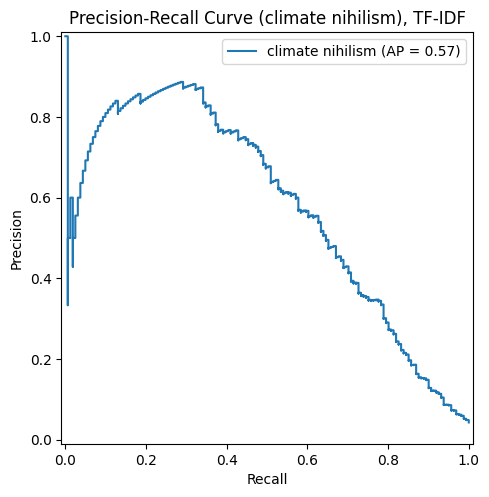

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import PrecisionRecallDisplay
classes = baseline_clf.classes_
Y_test_bin = label_binarize(y_test, classes=classes)

y_score = baseline_clf.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(5,7))

target_class = "climate nihilism"
class_idx = list(classes).index(target_class)

PrecisionRecallDisplay.from_predictions(
    Y_test_bin[:, class_idx],
    y_score[:, class_idx],
    name=target_class,
    ax=ax
)

plt.legend(loc='best')
plt.title(f"Precision-Recall Curve ({target_class}), TF-IDF")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'tfidf__max_features': [3000, 5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.5, 0.75, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__use_idf': [True, False],
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator=baseline_clf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_

print(f"best params: {grid_search.best_params_}")
print(f"best cv score: {grid_search.best_score_}")

y_pred = best_clf.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


KeyboardInterrupt: 

## 9. Inspect top TF-IDF words for each class

Run this only if the TF-IDF model trained successfully.

In [ ]:
if 'baseline_clf' in globals() and hasattr(baseline_clf, 'classes_'):
    vectorizer = baseline_clf.named_steps["tfidf"]
    clf = baseline_clf.named_steps["clf"]
    feature_names = np.array(vectorizer.get_feature_names_out())

    for i, cls in enumerate(clf.classes_):
        print("" + "="*80)
        print("Class:", cls)
        print("="*80)
        top_idx = np.argsort(clf.coef_[i])[-20:][::-1]
        print(feature_names[top_idx])
else:
    print("TF-IDF model was not trained, so there are no top words yet.")

Class: climate action critique
['to' 'about' 'they' 'vegetarian' 'handling' 'we' 'something to' 'would'
 'do' 'worse' 'animals' 'rate' 'power' 'fight climate' 'longer' 'at the'
 'energy' 'renewables' 'were' 'going to']
Class: climate activism
['bernie' 'we' 'change and' 'on' 'this' 'we need' 'stop' 'sucks' 'protest'
 'fighting' 'earth' 'make' 'of the' 'need' 'planet' 'bot' 'bernie bot'
 'happy' 'focus' 'and']
Class: climate activism critique
['yes because' 'image' 'she' 'her' 'now' 'policy' 'yes' 'because' 'world'
 'media' 'west' 'the' 'the damage' 'are causing' 'we are' 'greta' 'has'
 'of greenhouse' 'comment' 'the atmosphere']
Class: climate anxiety
['sad' 'makes me' 'existential' 'bc' 'life' 'worried' 'worried about'
 'kids' 'snow' 'against' 'having' 'also the' 'having kids' 'makes' 'me'
 'all of' 'what kind' 'planet is' 'you don' 'coming']
Class: climate apathy
['who is' 'care' 'upvotes' 'ang' 'don care' 'omsk' 'for climate' 'ng'
 'to save' 'position' 'using' 'they' 'save' 'boomers